In [38]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from Preprocess import preprocess_data_window
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [39]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")

In [40]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 6

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, n_previous_events
)

print("NaN count per column:\n", X_train.isna().sum())
print("Total NaN:", X_train.isna().sum().sum())

X shape:  (2822, 126)
y shape:  (2822,)
NaN count per column:
 tide_deriv-0      0
form_fac-0        0
time_since-0      0
slip_size-0       0
high_t_evt-0      0
                 ..
form_fac-20       0
time_since-20     0
slip_size-20      0
high_t_evt-20     0
tide_height-20    0
Length: 126, dtype: int64
Total NaN: 0


In [41]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "num_layers_per_event": 2,
    "shots": 4078,
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "XGBoost"
n_previous_events = 20

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)

QRC Config: {'num_layers_per_event': 2, 'shots': 4078, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: XGBoost


In [42]:
# ── Cell 5+6: Scaling only ────────────────────────────────────────────────────
def scale_to_pi_range(X_train, X_val, X_test):
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_sel = X_train.to_numpy()
X_val_sel   = X_val.to_numpy()
X_test_sel  = X_test.to_numpy()

X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits
n_total_events = n_previous_events + 1

print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")
print(f"Total events per sample: {n_total_events}")

Input to quantum circuit: (1692, 126)
n_qubits: 6, n_states: 64
Total events per sample: 21


In [43]:
# ── Cell 7: QESN with FC-TFI reservoir ───────────────────────────────────────
def generate_ising_params(n_qubits, rng, J_std=0.5, h=1.0, t=0.5):
    """
    FC-TFI Hamiltonian parameters — same as best performing run.
    """
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


def encode_memory(qc, memory_state, n_qubits):
    """
    Encode memory from previous event into the circuit.
    Memory state is the Pauli expectation values from the previous
    event's circuit — re-encoded as rotation angles.
    This creates genuine temporal coupling between events.

    memory_state: array of shape (3 * n_qubits,) — Z, X, Y expectations
                  from previous event, values in [-1, 1]
                  Re-scaled to [0, pi] for rotation encoding.
    """
    # Rescale from [-1, 1] to [0, pi]
    memory_angles = (memory_state[:n_qubits] + 1) * np.pi / 2

    for i in range(n_qubits):
        # Encode memory as Rz rotations — orthogonal to Ry data encoding
        # so memory and input don't interfere on the same rotation axis
        qc.rz(float(memory_angles[i]), i)


def build_reservoir_circuit_qesn(
    data_sample, memory_state, ising_params, num_layers, n_qubits
):
    """
    QESN circuit: encodes both current input AND memory from previous event.

    Structure:
      H layer → encode input (Ry) → encode memory (Rz) →
      FC-TFI evolution → re-upload input → re-upload memory →
      FC-TFI evolution → (repeat for num_layers)

    The memory encoding is the key difference from standard QRC.
    Previous event's quantum state influences current event's circuit,
    creating genuine temporal dynamics rather than independent projections.
    If memory_state is None (first event), memory encoding is skipped.
    """
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)

    # Initial superposition
    for i in range(n_qubits):
        qc.h(i)

    # Encode current input
    encode_rotations(qc, data_sample, n_qubits)

    # Encode memory from previous event if available
    if memory_state is not None:
        encode_memory(qc, memory_state, n_qubits)

    qc.barrier()

    for layer in range(num_layers):
        # FC-TFI evolution
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

        # Re-upload input
        encode_rotations(qc, data_sample, n_qubits)

        # Re-upload memory
        if memory_state is not None:
            encode_memory(qc, memory_state, n_qubits)

        qc.barrier()

        # Second FC-TFI evolution
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

    return qc


def generate_random_angles(num_layers, n_qubits, rng):
    """Returns Ising params for API compatibility."""
    return generate_ising_params(n_qubits, rng)

In [44]:
# ── Cell 8: Pauli runner + adaptive decay ─────────────────────────────────────
def get_pauli_expectations(circuit_base, n_qubits, shots, simulator):
    """
    Measure X, Y, Z expectations plus ZZ correlators.
    Returns shape (3 * n_qubits + n_qubits,) = (24,) for 6 qubits.
    """
    expectations = np.zeros(3 * n_qubits)

    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        qc_meas = circuit_base.copy()

        if basis == 'X':
            for i in range(n_qubits):
                qc_meas.h(i)
        elif basis == 'Y':
            for i in range(n_qubits):
                qc_meas.sdg(i)
                qc_meas.h(i)

        qc_meas.measure_all()
        result = simulator.run(qc_meas, shots=shots).result()
        counts = result.get_counts()

        for bitstring, count in counts.items():
            bits = bitstring.replace(" ", "")
            for qubit_idx in range(n_qubits):
                bit = int(bits[n_qubits - 1 - qubit_idx])
                expectations[basis_idx * n_qubits + qubit_idx] += (
                    (1 - 2 * bit) * count / shots
                )

    # ZZ correlators on ring topology
    zz_correlators = np.zeros(n_qubits)
    qc_zz = circuit_base.copy()
    qc_zz.measure_all()
    result_zz = simulator.run(qc_zz, shots=shots).result()
    counts_zz = result_zz.get_counts()

    for bitstring, count in counts_zz.items():
        bits = bitstring.replace(" ", "")
        for i in range(n_qubits):
            j = (i + 1) % n_qubits
            bit_i = int(bits[n_qubits - 1 - i])
            bit_j = int(bits[n_qubits - 1 - j])
            zz_correlators[i] += (1 - 2*bit_i) * (1 - 2*bit_j) * count / shots

    return np.concatenate([expectations, zz_correlators])  # shape (24,)


def run_quantum_reservoir_pauli(
    X_data, angle_bank, num_layers, n_qubits, n_total_events, shots
):
    """
    FC-TFI Pauli reservoir runner.
    Output shape: (m, n_total_events * 24).
    """
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m         = X_data.shape[0]
    n_obs     = 3 * n_qubits + n_qubits  # 24
    simulator = AerSimulator()
    pauli_matrix = np.zeros((m, n_total_events * n_obs))

    for event_idx in range(n_total_events):
        start_col     = event_idx * n_qubits
        end_col       = start_col + n_qubits
        X_event       = X_data[:, start_col:end_col]
        ising_params  = angle_bank[event_idx]

        for sample_idx in range(m):
            qc = build_reservoir_circuit_rotations(
                X_event[sample_idx], ising_params, num_layers, n_qubits
            )
            obs_vals = get_pauli_expectations(qc, n_qubits, shots, simulator)
            pauli_matrix[
                sample_idx,
                event_idx * n_obs:(event_idx + 1) * n_obs
            ] = obs_vals

        print(f"  Event {event_idx + 1}/{n_total_events} done", end="\r")

    print()
    return pauli_matrix


def make_hybrid_features(P, X_classical):
    """Standard unweighted hybrid features — kept for compatibility."""
    return np.hstack([P, X_classical])


def make_hybrid_features_adaptive_decay(
    P_matrix, X_classical, X_raw, n_total_events, n_obs,
    time_since_slip_idx=5, base_decay=0.3
):
    """
    Adaptive exponential decay weighting per sample.

    Looks at the last 5 events in each sample's window and computes
    the mean recent inter-event time. Samples with long recent intervals
    (slow-slip regime) get softer decay=0.1 so the full history is
    weighted more equally — the slow regime has been persistent and
    older context is still relevant. Samples with short recent intervals
    (fast-slip regime) get steeper decay=0.5 so recent events dominate.

    decay range: 0.1 (slow regime) to 0.5 (fast regime)
    """
    m = P_matrix.shape[0]
    weighted_P = P_matrix.copy()
    n_features_per_event = X_raw.shape[1] // n_total_events

    # Get recent inter-event times from last 5 events per sample
    recent_intervals = []
    for event_idx in range(max(0, n_total_events - 5), n_total_events):
        col = event_idx * n_features_per_event + time_since_slip_idx
        if col < X_raw.shape[1]:
            recent_intervals.append(X_raw[:, col])

    if len(recent_intervals) > 0:
        recent_mean = np.stack(recent_intervals, axis=1).mean(axis=1)

        # Normalize to [0, 1] across all samples
        r_min = recent_mean.min()
        r_max = recent_mean.max()
        if r_max > r_min:
            normalized = (recent_mean - r_min) / (r_max - r_min)
        else:
            normalized = np.zeros(m)

        # Slow regime (normalized→1) → decay 0.1
        # Fast regime (normalized→0) → decay 0.5
        per_sample_decay = 0.5 - normalized * 0.4
    else:
        per_sample_decay = np.full(m, base_decay)

    # Apply per-sample exponential decay weights to each event block
    for sample_idx in range(m):
        decay = per_sample_decay[sample_idx]
        weights = np.array([
            np.exp(-decay * (n_total_events - 1 - i))
            for i in range(n_total_events)
        ])
        weights /= weights.sum()

        for event_idx in range(n_total_events):
            start = event_idx * n_obs
            end   = start + n_obs
            weighted_P[sample_idx, start:end] *= weights[event_idx]

    return np.hstack([weighted_P, X_classical])

In [45]:
# ── Cell 9: Model registry ───────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 6),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.8),
                "min_child_weight": trial.suggest_int("min_child_weight", 3, 20),
                # Push harder on regularization — 1470-dim input needs it
                "reg_alpha":        trial.suggest_float("reg_alpha", 0.1, 50.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
                # Limit tree complexity on high-dim noisy input
                "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
                "max_delta_step":   trial.suggest_int("max_delta_step", 0, 5),
            },
            "fixed_params": {
                "objective":             "reg:squarederror",
                "n_estimators":          2000,
                "random_state":          42,
                "early_stopping_rounds": 75,  # more patience on larger feature set
                "tree_method":           "hist",  # faster on wide feature matrices
            },
            "build_fn": lambda params: XGBRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=[(Xv, yv)], verbose=False
            ),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(
                Xt, yt, eval_set=(Xv, yv), use_best_model=True
            ),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")

Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: XGBoost


In [46]:
# ── Cell 10: Single iteration — FC-TFI + adaptive decay ──────────────────────
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    num_layers     = config["num_layers_per_event"]
    shots          = config["shots"]
    seed           = config["random_seed"] + iteration_idx
    n_total_events = n_previous_events + 1
    n_obs          = 3 * n_qubits + n_qubits  # 24

    rng = np.random.default_rng(seed)
    angle_bank = [
        generate_random_angles(num_layers, n_qubits, rng)
        for _ in range(n_total_events)
    ]

    print(f"  Running FC-TFI on train ({X_train_q.shape[0]} samples)...")
    P_train = run_quantum_reservoir_pauli(
        X_train_q, angle_bank, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running FC-TFI on val ({X_val_q.shape[0]} samples)...")
    P_val = run_quantum_reservoir_pauli(
        X_val_q, angle_bank, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running FC-TFI on test ({X_test_q.shape[0]} samples)...")
    P_test = run_quantum_reservoir_pauli(
        X_test_q, angle_bank, num_layers, n_qubits, n_total_events, shots
    )

    # Adaptive decay — per sample decay based on recent slip regime
    H_train = make_hybrid_features_adaptive_decay(
        P_train, X_train_q, X_train_q, n_total_events, n_obs
    )
    H_val = make_hybrid_features_adaptive_decay(
        P_val, X_val_q, X_val_q, n_total_events, n_obs
    )
    H_test = make_hybrid_features_adaptive_decay(
        P_test, X_test_q, X_test_q, n_total_events, n_obs
    )

    entry = registry[model_name]

    def objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        model  = entry["build_fn"](params)
        entry["fit_fn"](model, H_train, y_train, H_val, y_val)
        preds  = model.predict(H_val)
        return mean_absolute_error(y_val, preds)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=50)

    best_tuned  = entry["optuna_fn"](study.best_trial)
    best_params = {**entry["fixed_params"], **best_tuned}
    model       = entry["build_fn"](best_params)
    entry["fit_fn"](model, H_train, y_train, H_val, y_val)

    val_pred  = model.predict(H_val)
    test_pred = model.predict(H_test)

    return {
        "iteration":   iteration_idx,
        "val_r2":      r2_score(y_val, val_pred),
        "val_rmse":    root_mean_squared_error(y_val, val_pred),
        "val_mae":     mean_absolute_error(y_val, val_pred),
        "test_rmse":   root_mean_squared_error(y_test, test_pred),
        "test_mae":    mean_absolute_error(y_test, test_pred),
        "test_pred":   test_pred,
        "best_params": best_params,
        "model":       model,
        "P_train": P_train, "P_val": P_val, "P_test": P_test,
    }

In [47]:
# ── Cell 11: Pipeline + run ──────────────────────────────────────────────────
def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            X_train_q, X_val_q, X_test_q,
            y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    top_k          = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results    = sorted_results[:top_k]
    top_indices    = [r["iteration"] for r in top_results]

    print(f"\nTop-{top_k} iterations (by val MAE): {[i + 1 for i in top_indices]}")

    ensemble_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    ensemble_rmse = root_mean_squared_error(y_test, ensemble_pred)
    ensemble_mae  = mean_absolute_error(y_test, ensemble_pred)
    ensemble_r2   = r2_score(y_test, ensemble_pred)

    print(f"\nEnsemble Test RMSE: {ensemble_rmse:.2f}")
    print(f"Ensemble Test MAE:  {ensemble_mae:.2f}")
    print(f"Ensemble Test R2:   {ensemble_r2:.4f}")

    return results, ensemble_pred, top_indices


all_results, ensemble_pred, top_indices = run_qrc_pipeline(
    X_train_q,
    X_val_q,
    X_test_q,
    y_train,
    y_val,
    y_test,
    n_qubits,
    QRC_CONFIG,
    "XGBoost",
    registry,
)


Iteration 1/5:
  Running FC-TFI on train (1692 samples)...
  Event 21/21 done
  Running FC-TFI on val (565 samples)...
  Event 21/21 done
  Running FC-TFI on test (565 samples)...
  Event 21/21 done
	Val R2: 0.2928 | Val RMSE: 16872.53 | Val MAE: 13056.56 | Test RMSE: 15844.63 | Test MAE: 12236.46

Iteration 2/5:
  Running FC-TFI on train (1692 samples)...
  Event 21/21 done
  Running FC-TFI on val (565 samples)...
  Event 21/21 done
  Running FC-TFI on test (565 samples)...
  Event 21/21 done
	Val R2: 0.2703 | Val RMSE: 17139.57 | Val MAE: 13362.11 | Test RMSE: 15365.98 | Test MAE: 11864.75

Iteration 3/5:
  Running FC-TFI on train (1692 samples)...
  Event 21/21 done
  Running FC-TFI on val (565 samples)...
  Event 21/21 done
  Running FC-TFI on test (565 samples)...
  Event 21/21 done
	Val R2: 0.2924 | Val RMSE: 16877.55 | Val MAE: 13194.31 | Test RMSE: 15294.81 | Test MAE: 11891.15

Iteration 4/5:
  Running FC-TFI on train (1692 samples)...
  Event 21/21 done
  Running FC-TFI on v

In [48]:
import pickle
import os

run_label = "Hamil-QSEN-QRC_pauli"  # change per run

save_data = {
    "ensemble_pred": ensemble_pred,
    "y_test": y_test,
    "all_results": [
        {k: v for k, v in r.items() if k != "model"}
        for r in all_results
    ],
    "ensemble_mae": mean_absolute_error(y_test, ensemble_pred),
    "ensemble_rmse": root_mean_squared_error(y_test, ensemble_pred),
    "ensemble_r2": r2_score(y_test, ensemble_pred),
}

os.makedirs("results", exist_ok=True)
with open(f"results/{run_label}.pkl", "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved results to results/{run_label}.pkl")

Saved results to results/Hamil-QSEN-QRC_pauli.pkl


Sample 0: True = 87450s, Predicted = 60436s, Error = 27014s
Sample 1: True = 58215s, Predicted = 56364s, Error = 1851s
Sample 2: True = 88560s, Predicted = 79496s, Error = 9064s
Sample 3: True = 31005s, Predicted = 63106s, Error = 32101s
Sample 4: True = 36825s, Predicted = 60500s, Error = 23675s
Sample 5: True = 95370s, Predicted = 71483s, Error = 23887s
Sample 6: True = 61440s, Predicted = 65190s, Error = 3750s
Sample 7: True = 52110s, Predicted = 64064s, Error = 11954s
Sample 8: True = 56520s, Predicted = 56681s, Error = 161s
Sample 9: True = 35355s, Predicted = 54565s, Error = 19210s
Sample 10: True = 87870s, Predicted = 81868s, Error = 6002s
Sample 11: True = 31620s, Predicted = 69779s, Error = 38159s
Sample 12: True = 39930s, Predicted = 52335s, Error = 12405s
Sample 13: True = 28455s, Predicted = 61918s, Error = 33463s
Sample 14: True = 33600s, Predicted = 53930s, Error = 20330s
Sample 15: True = 53310s, Predicted = 55066s, Error = 1756s
Sample 16: True = 37860s, Predicted = 787

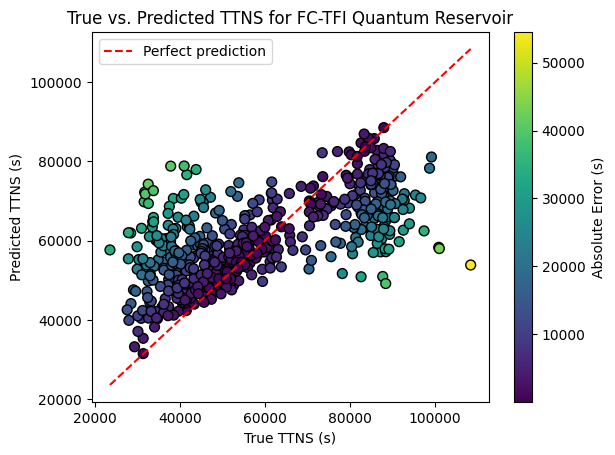


MAE:  11893.45s
RMSE: 15306.24s
R2:   0.4224


In [49]:
# ── Predicted vs True plot for FC-TFI Quantum Reservoir ──────────────────────
import matplotlib.pyplot as plt
y_test_secs = y_test
QRC_pred_secs = ensemble_pred  # this is the output from run_qrc_pipeline

absolute_error_secs_QRC = np.abs(QRC_pred_secs - y_test_secs)

# Print true vs predicted for every record
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, QRC_pred_secs, absolute_error_secs_QRC)):
    print(f"Sample {i}: True = {true:.0f}s, Predicted = {pred:.0f}s, Error = {abs_error:.0f}s")

# Scatter plot
plt.figure()
plt.scatter(y_test_secs, QRC_pred_secs, c=absolute_error_secs_QRC, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)], 
         color='red', linestyle='--', label='Perfect prediction')
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for FC-TFI Quantum Reservoir")
plt.legend()
plt.show()

print(f"\nMAE:  {mean_absolute_error(y_test_secs, QRC_pred_secs):.2f}s")
print(f"RMSE: {root_mean_squared_error(y_test_secs, QRC_pred_secs):.2f}s")
print(f"R2:   {r2_score(y_test_secs, QRC_pred_secs):.4f}")

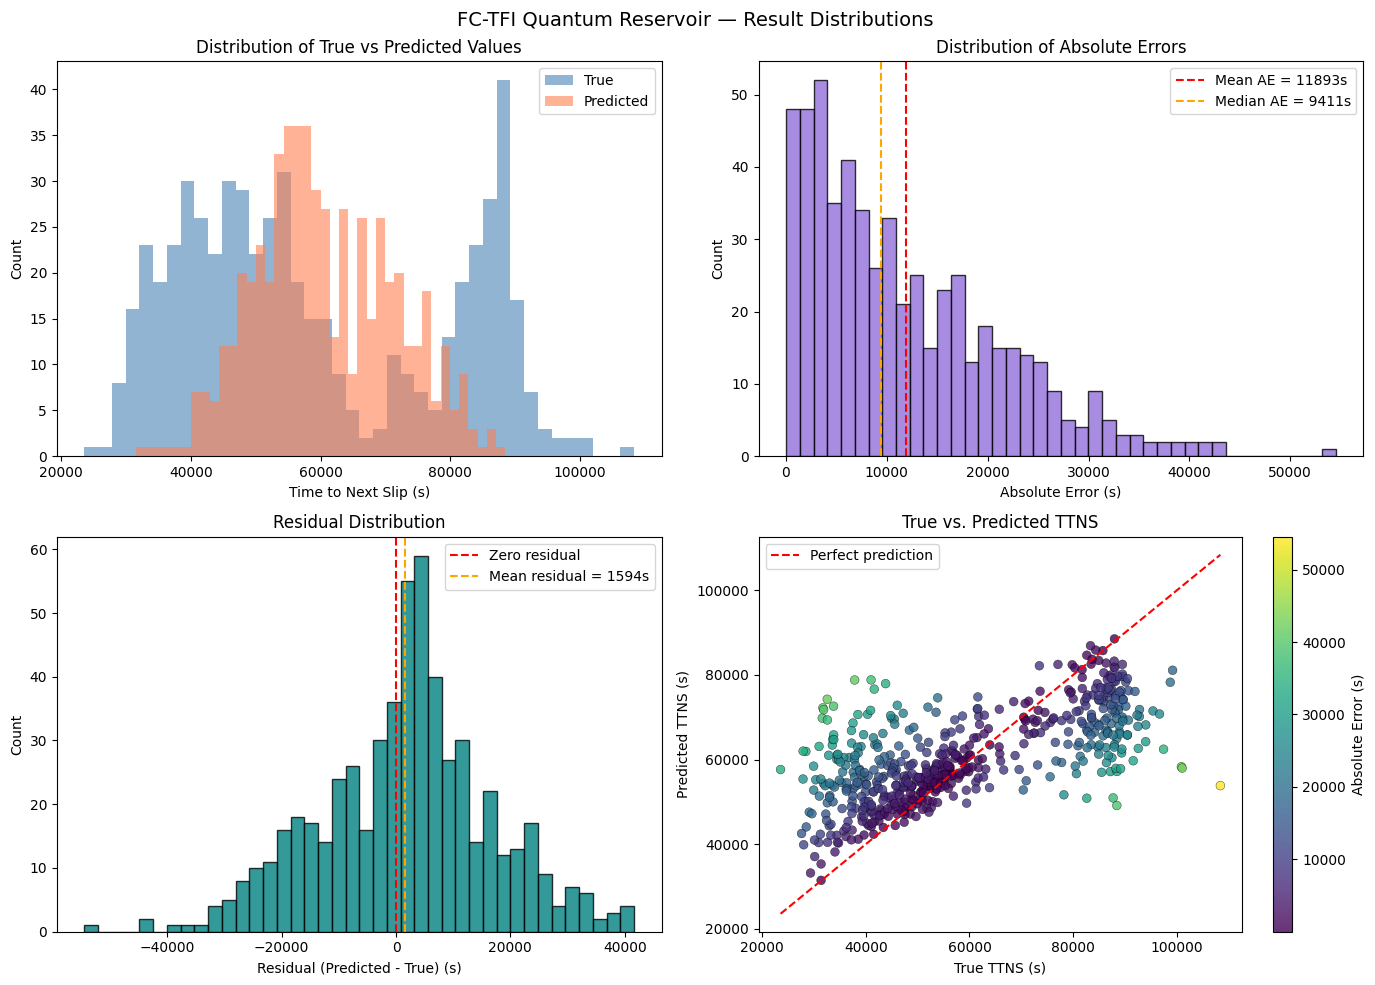

MAE:            11893.45s
Median AE:      9411.12s
RMSE:           15306.24s
R2:             0.4224
Max error:      54517.01s
% within 5000s: 29.9%
% within 9000s: 48.7%


In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# ── Data distribution plot for FC-TFI run ────────────────────────────────────
y_test_secs    = y_test
QRC_pred_secs  = ensemble_pred

absolute_errors = np.abs(QRC_pred_secs - y_test_secs)
residuals       = QRC_pred_secs - y_test_secs

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FC-TFI Quantum Reservoir — Result Distributions", fontsize=14)

# ── Panel 1: Distribution of true vs predicted values ────────────────────────
axes[0, 0].hist(y_test_secs, bins=40, alpha=0.6, color='steelblue', label='True')
axes[0, 0].hist(QRC_pred_secs, bins=40, alpha=0.6, color='coral', label='Predicted')
axes[0, 0].set_xlabel("Time to Next Slip (s)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of True vs Predicted Values")
axes[0, 0].legend()

# ── Panel 2: Distribution of absolute errors ──────────────────────────────────
axes[0, 1].hist(absolute_errors, bins=40, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(absolute_errors.mean(), color='red', linestyle='--',
                    label=f'Mean AE = {absolute_errors.mean():.0f}s')
axes[0, 1].axvline(np.median(absolute_errors), color='orange', linestyle='--',
                    label=f'Median AE = {np.median(absolute_errors):.0f}s')
axes[0, 1].set_xlabel("Absolute Error (s)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Absolute Errors")
axes[0, 1].legend()

# ── Panel 3: Residuals distribution ──────────────────────────────────────────
axes[1, 0].hist(residuals, bins=40, color='teal', edgecolor='black', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[1, 0].axvline(residuals.mean(), color='orange', linestyle='--',
                    label=f'Mean residual = {residuals.mean():.0f}s')
axes[1, 0].set_xlabel("Residual (Predicted - True) (s)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distribution")
axes[1, 0].legend()

# ── Panel 4: True vs Predicted scatter ───────────────────────────────────────
sc = axes[1, 1].scatter(y_test_secs, QRC_pred_secs,
                         c=absolute_errors, cmap='viridis',
                         s=40, edgecolors='black', linewidths=0.3, alpha=0.8)
plt.colorbar(sc, ax=axes[1, 1], label="Absolute Error (s)")
axes[1, 1].plot([y_test_secs.min(), y_test_secs.max()],
                [y_test_secs.min(), y_test_secs.max()],
                'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 1].set_xlabel("True TTNS (s)")
axes[1, 1].set_ylabel("Predicted TTNS (s)")
axes[1, 1].set_title("True vs. Predicted TTNS")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"MAE:            {mean_absolute_error(y_test_secs, QRC_pred_secs):.2f}s")
print(f"Median AE:      {np.median(absolute_errors):.2f}s")
print(f"RMSE:           {np.sqrt(np.mean(residuals**2)):.2f}s")
print(f"R2:             {r2_score(y_test_secs, QRC_pred_secs):.4f}")
print(f"Max error:      {absolute_errors.max():.2f}s")
print(f"% within 5000s: {(absolute_errors < 5000).mean()*100:.1f}%")
print(f"% within 9000s: {(absolute_errors < 9000).mean()*100:.1f}%")

In [51]:
# ── Cell 12: Classical baseline diagnostic ───────────────────────────────────
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

last_res = all_results[-1]
P_dim = last_res["P_train"].shape[1]

H_train = np.hstack([last_res["P_train"], X_train_q])
H_val   = np.hstack([last_res["P_val"],   X_val_q])
H_test  = np.hstack([last_res["P_test"],  X_test_q])

X_tr_raw = H_train[:, P_dim:]
X_v_raw  = H_val[:,   P_dim:]
X_te_raw = H_test[:,  P_dim:]

classical_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    early_stopping_rounds=75,
    tree_method="hist",
    random_state=42,
)

classical_model.fit(
    X_tr_raw, y_train,
    eval_set=[(X_v_raw, y_val)],
    verbose=False
)

classical_pred = classical_model.predict(X_te_raw)
classical_mae  = mean_absolute_error(y_test, classical_pred)
quantum_mae    = last_res["test_mae"]

print(f"Classical XGBoost (126 features, no quantum): MAE = {classical_mae:.2f}")
print(f"Quantum hybrid (single iteration):            MAE = {quantum_mae:.2f}")
print(f"Quantum vs classical difference:              {quantum_mae - classical_mae:.2f}s")

Classical XGBoost (126 features, no quantum): MAE = 11671.34
Quantum hybrid (single iteration):            MAE = 12123.62
Quantum vs classical difference:              452.28s
